In [36]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
df = pd.read_csv("raw_metadata.csv")
print(df.info())

print("Dataset Shape:", df.shape)

print("First 5 rows:")
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   video_id      132 non-null    str  
 1   title         132 non-null    str  
 2   publish_date  132 non-null    str  
dtypes: str(3)
memory usage: 3.2 KB
None
Dataset Shape: (132, 3)
First 5 rows:


,video_id,title,publish_date
0,w9319SXPOmg,IIT Kanpur : Tech Talk &amp; 5 Powerful Lesson...,2026-02-20 17:03:27+00:00
1,lxhCssNum64,17 LPA+ @ HPE : Best Strategy for Placement🚀,2026-02-17 15:32:19+00:00
2,eqPu9ge4Cxs,How this student got placed in Hwelett Packard...,2026-02-06 16:44:27+00:00
3,qp5F76yz-y8,Complete Data Structures &amp; Algorithms + Ap...,2026-01-30 16:34:49+00:00
4,jqzvBsIfEBM,How he got selected in Zomato - DSA preparation,2025-12-07 15:54:48+00:00


In [39]:
print("Column Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nTotal Rows:", len(df))

Column Names: ['video_id', 'title', 'publish_date']

Data Types:
video_id        str
title           str
publish_date    str
dtype: object

Total Rows: 132


In [40]:
print("Duplicate video_id:", df["video_id"].duplicated().sum())
print("Duplicate titles:", df["title"].duplicated().sum())
#if any duplicates are found in dataset
df = df.drop_duplicates(subset="video_id")
print("Shape after removing duplicates:", df.shape)

Duplicate video_id: 0
Duplicate titles: 0
Shape after removing duplicates: (132, 3)


In [41]:
print("Missing values:\n")
df.isnull().sum()

Missing values:



video_id        0
title           0
publish_date    0
dtype: int64

In [42]:
df = df.dropna(subset=["video_id", "title", "publish_date"])
print("Shape after removing nulls:", df.shape)

Shape after removing nulls: (132, 3)


In [43]:
df["publish_date"] = pd.to_datetime(df["publish_date"], errors="coerce")

df["year"] = df["publish_date"].dt.year
df["month"] = df["publish_date"].dt.month

df.head()

,video_id,title,publish_date,year,month
0,w9319SXPOmg,IIT Kanpur : Tech Talk &amp; 5 Powerful Lesson...,2026-02-20 17:03:27+00:00,2026,2
1,lxhCssNum64,17 LPA+ @ HPE : Best Strategy for Placement🚀,2026-02-17 15:32:19+00:00,2026,2
2,eqPu9ge4Cxs,How this student got placed in Hwelett Packard...,2026-02-06 16:44:27+00:00,2026,2
3,qp5F76yz-y8,Complete Data Structures &amp; Algorithms + Ap...,2026-01-30 16:34:49+00:00,2026,1
4,jqzvBsIfEBM,How he got selected in Zomato - DSA preparation,2025-12-07 15:54:48+00:00,2025,12


In [44]:
videos_per_year = df.groupby("year").size()
videos_per_year

year
2020     4
2021    33
2022    28
2023    17
2024    29
2025    17
2026     4
dtype: int64

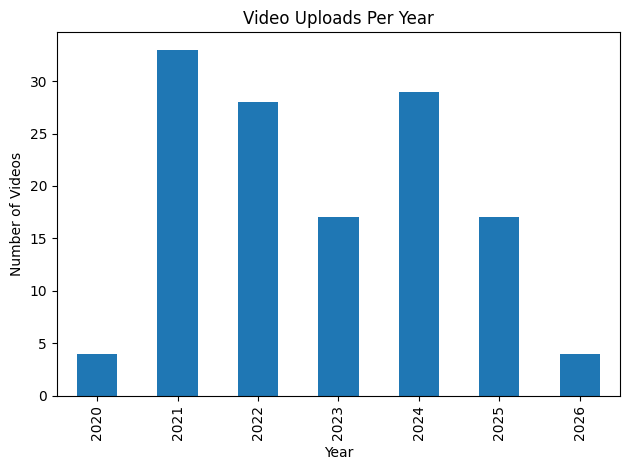

In [45]:
videos_per_year.plot(kind="bar", title="Video Uploads Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Videos")
plt.tight_layout()
plt.show()

In [46]:
videos_per_month = df.groupby("month").size()
videos_per_month

month
1     15
2     12
3      8
4     10
5      8
6      8
7      5
8      8
9     15
10    14
11    15
12    14
dtype: int64

Title Analysis


In [ ]:
df["title"] = df["title"].astype(str)
df["title_length"] = df["title"].str.len()

In [48]:
#for shortest title
print(df.loc[df["title_length"].idxmin(), "title"])
#for longest title
print(df.loc[df["title_length"].idxmax(), "title"])
#average title length
print(df["title_length"].mean())

Amazon CTC Breakdown
Introduction to Web Development | World&#39;s most premium Web Development Course | Lecture 0 (Reupload)
63.14393939393939


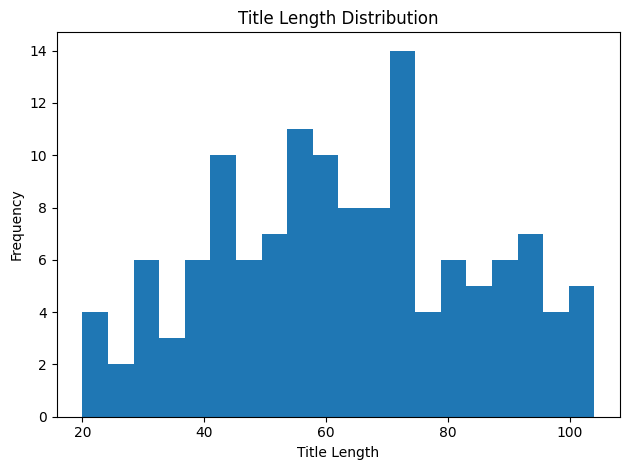

In [49]:
#Plot distribution of title lengths 
df["title_length"].plot(kind="hist", bins=20, title="Title Length Distribution")
plt.xlabel("Title Length")
plt.tight_layout()
plt.show()

In [50]:
print("Total Unique Videos:", df["video_id"].nunique())
print("Date Range:", df["publish_date"].min(), "to", df["publish_date"].max())

Total Unique Videos: 132
Date Range: 2020-10-31 17:05:48+00:00 to 2026-02-20 17:03:27+00:00


In [51]:
if 100 <= len(df) <= 350:
    print("Dataset size within recommended range ✅")
else:
    print("Dataset size outside recommended range ⚠")

Dataset size within recommended range ✅


In [52]:
df["title"] = df["title"].str.strip()
df["title"] = df["title"].str.replace("\n", " ", regex=False)

df.head()

,video_id,title,publish_date,year,month,title_length
0,w9319SXPOmg,IIT Kanpur : Tech Talk &amp; 5 Powerful Lesson...,2026-02-20 17:03:27+00:00,2026,2,70
1,lxhCssNum64,17 LPA+ @ HPE : Best Strategy for Placement🚀,2026-02-17 15:32:19+00:00,2026,2,44
2,eqPu9ge4Cxs,How this student got placed in Hwelett Packard...,2026-02-06 16:44:27+00:00,2026,2,88
3,qp5F76yz-y8,Complete Data Structures &amp; Algorithms + Ap...,2026-01-30 16:34:49+00:00,2026,1,93
4,jqzvBsIfEBM,How he got selected in Zomato - DSA preparation,2025-12-07 15:54:48+00:00,2025,12,47


In [53]:
df.to_csv("cleaned_metadata.csv", index=False)
print("Cleaned dataset saved as cleaned_metadata.csv")

Cleaned dataset saved as cleaned_metadata.csv
